In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats
from scipy.stats import zscore

In [25]:
# Load dataset
df = pd.read_csv('../data/togo-dapaong_qc.csv')  

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-nul

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


In [26]:
# Missing values count
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing[missing_percent > 5]  # columns with >5% missing

Comments    525600
dtype: int64

In [28]:
# Columns to check
cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Compute Z-scores
z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).any(axis=1)
print("Number of outlier rows:", outliers.sum())

# Impute missing values with median
for col in cols:
    df[col] = df[col].fillna(df[col].median())

# drop outliers
df_clean = df[~outliers].copy()

Number of outlier rows: 9251


In [29]:
df_clean.to_csv('../data/togo_clean.csv', index=False)

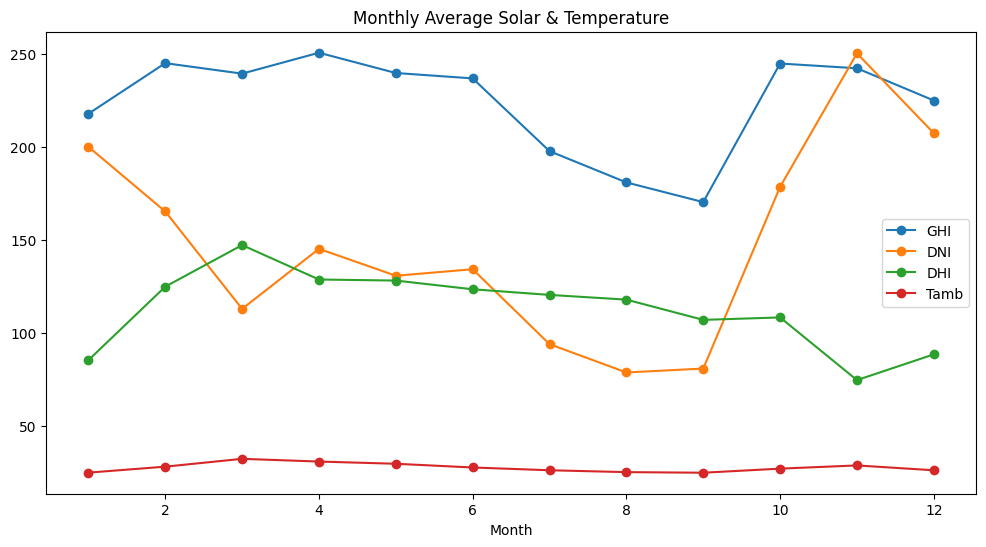

In [30]:
# Convert timestamp to datetime
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# Monthly averages
df_clean['Month'] = df_clean['Timestamp'].dt.month
monthly_avg = df_clean.groupby('Month')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()
monthly_avg.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Monthly Average Solar & Temperature")
plt.show()

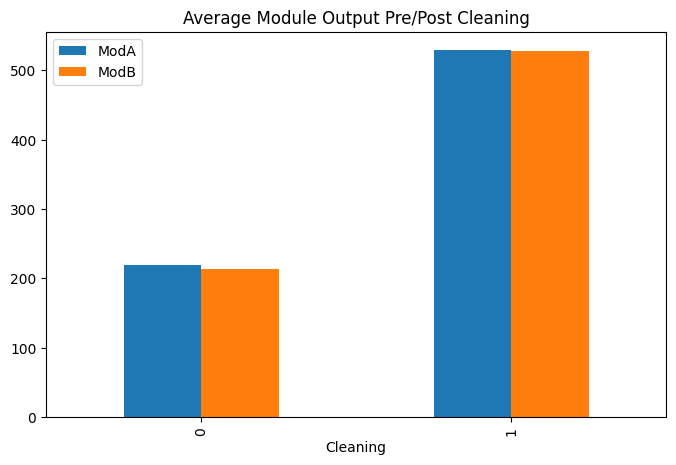

In [31]:
df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Module Output Pre/Post Cleaning")
plt.show()

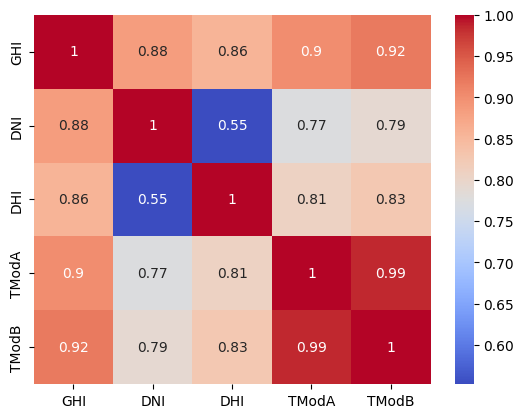

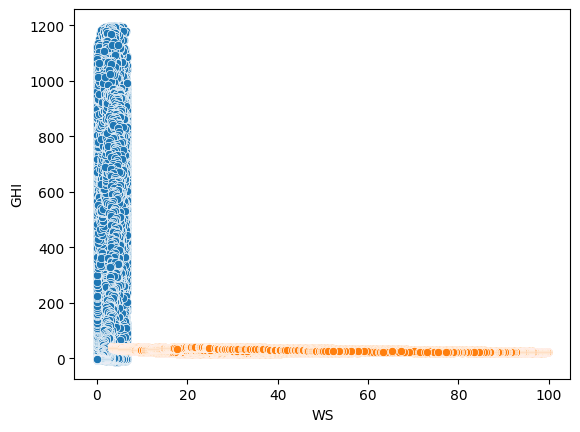

In [32]:
# Correlation heatmap
sns.heatmap(df_clean[['GHI','DNI','DHI','TModA','TModB']].corr(), annot=True, cmap='coolwarm')
plt.show()

# Scatter plots
sns.scatterplot(x='WS', y='GHI', data=df_clean)
sns.scatterplot(x='RH', y='Tamb', data=df_clean)
plt.show()

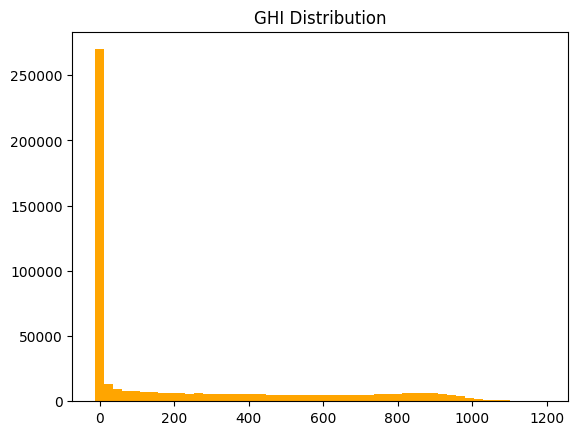

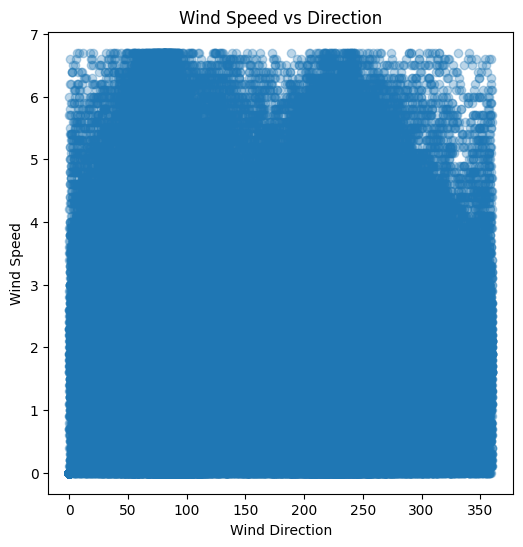

In [33]:
# Histogram of GHI
plt.hist(df_clean['GHI'], bins=50, color='orange')
plt.title("GHI Distribution")
plt.show()

# Wind rose approximation
plt.figure(figsize=(6,6))
plt.scatter(df_clean['WD'], df_clean['WS'], alpha=0.3)
plt.xlabel('Wind Direction')
plt.ylabel('Wind Speed')
plt.title('Wind Speed vs Direction')
plt.show()

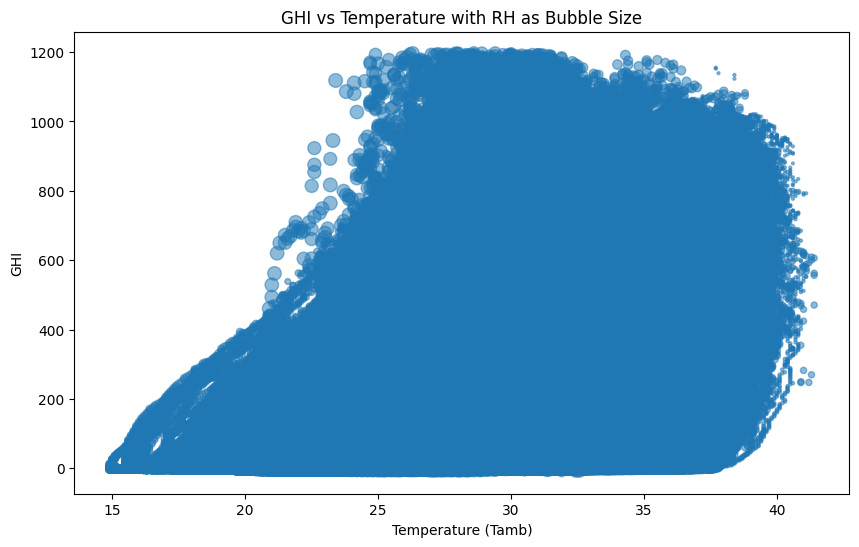

In [34]:
#Bubble chart
plt.figure(figsize=(10,6))
plt.scatter(df_clean['Tamb'], df_clean['GHI'], s=df_clean['RH'], alpha=0.5)
plt.xlabel("Temperature (Tamb)")
plt.ylabel("GHI")
plt.title("GHI vs Temperature with RH as Bubble Size")
plt.show()

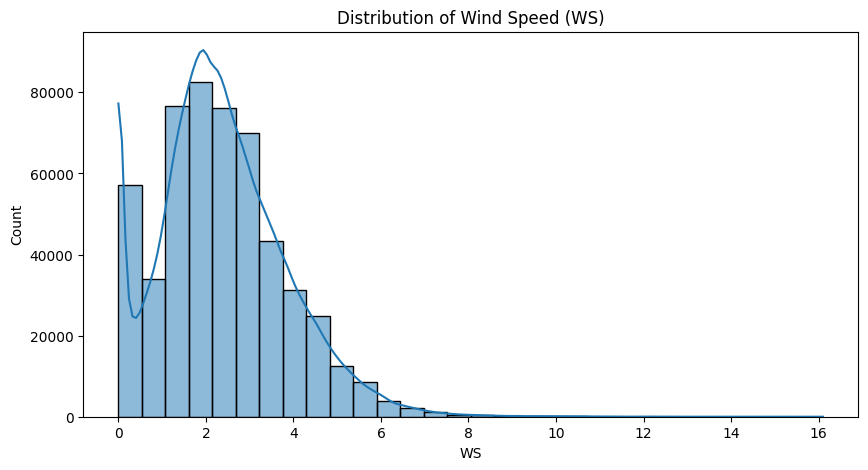

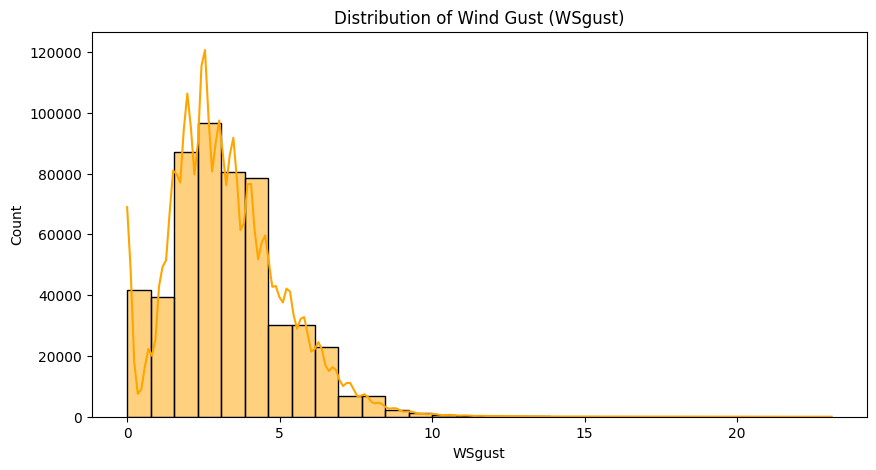

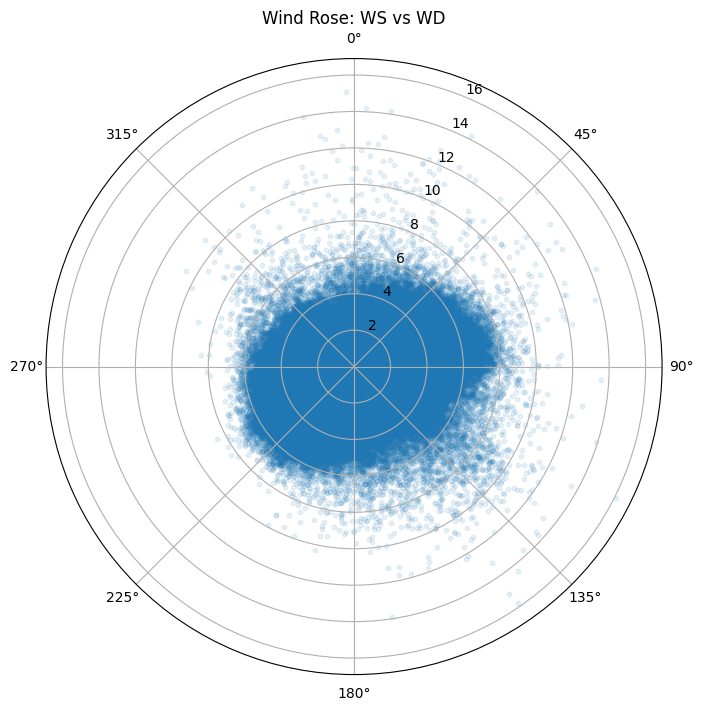

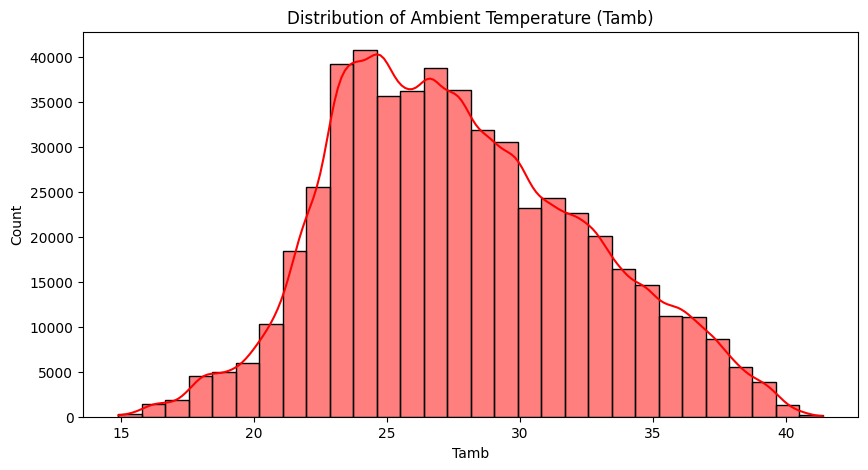

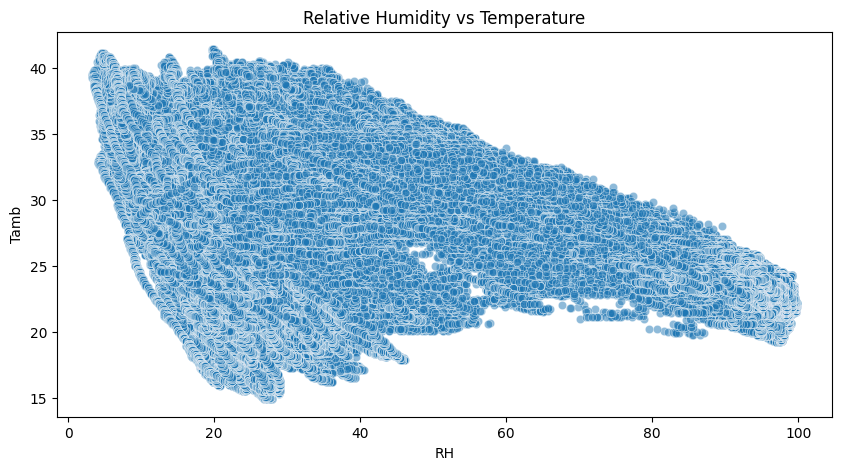

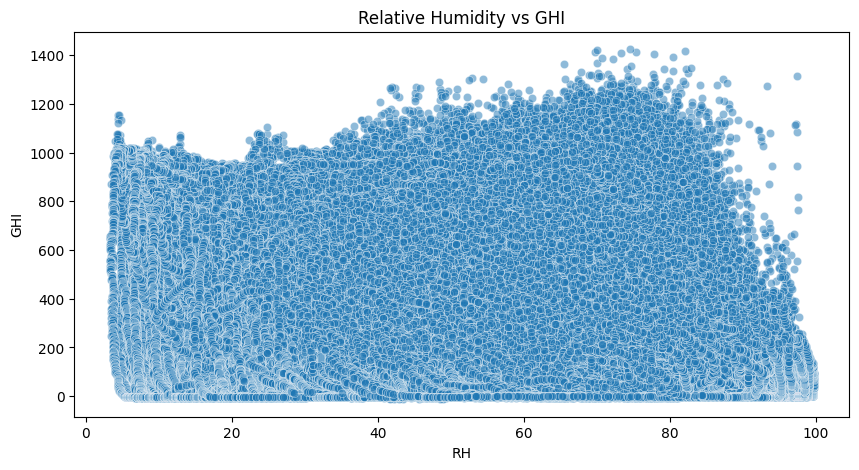

In [35]:
#Wind & distribution analysis

plt.figure(figsize=(10,5))
sns.histplot(df['WS'], bins=30, kde=True)
plt.title('Distribution of Wind Speed (WS)')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['WSgust'], bins=30, kde=True, color='orange')
plt.title('Distribution of Wind Gust (WSgust)')
plt.show()


# Wind rose (scatter version for speed)

theta = np.deg2rad(df['WD'])
r = df['WS']
plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)
ax.scatter(theta, r, alpha=0.1, s=10)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.title('Wind Rose: WS vs WD')
plt.show()

# Temperature analysis

plt.figure(figsize=(10,5))
sns.histplot(df['Tamb'], bins=30, kde=True, color='red')
plt.title('Distribution of Ambient Temperature (Tamb)')
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='RH', y='Tamb', alpha=0.5)
plt.title('Relative Humidity vs Temperature')
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='RH', y='GHI', alpha=0.5)
plt.title('Relative Humidity vs GHI')
plt.show()